In [1]:
data = ' https://raw.githubusercontent.com/DataTalksClub/machine-learning-zoomcamp/main/cohorts/2026/data/course_lead_scoring_2026.csv'

!wget $data -O homework-week-3.csv

--2026-10-08 23:37:48--  https://raw.githubusercontent.com/DataTalksClub/machine-learning-zoomcamp/main/cohorts/2026/data/course_lead_scoring_2026.csv
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.110.133, 185.199.108.133, 185.199.111.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.110.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 278746 (272K) [text/plain]
Saving to: ‘homework-week-3.csv’

homework-week-3.csv 100%[===================>] 272.21K  --.-KB/s    in 0.004s  

2026-10-08 23:37:48 (63.3 MB/s) - ‘homework-week-3.csv’ saved [278746/278746]



# Homework Evaluation

## Read data

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
# read csv
df = pd.read_csv('homework-week-3.csv')
df.head()

,lead_source,industry,employment_status,location,annual_income,number_of_courses_viewed,interaction_count,lead_score,converted
0,organic_search,technology,employed,europe,88160.0,3,4,0.64,1
1,social_media,technology,employed,south_america,72688.0,3,7,0.72,1
2,referral,retail,employed,europe,44697.0,3,4,0.58,1
3,paid_ads,manufacturing,student,NaN,NaN,3,6,0.57,0
4,referral,manufacturing,student,north_america,24062.0,4,5,0.62,1


## Data Preparation

In [9]:
df.isna().sum()

lead_source                 148
industry                    240
employment_status           194
location                    208
annual_income               369
number_of_courses_viewed      0
interaction_count             0
lead_score                   35
converted                     0
dtype: int64

In [38]:
categorical = ['lead_source', 'industry', 'employment_status', 'location']
numerical = ['annual_income', 'number_of_courses_viewed', 'interaction_count', 'lead_score']

In [39]:
df[categorical] = df[categorical].fillna('NA')
df[numerical] = df[numerical].fillna(0)

df.isna().sum()

lead_source                 0
industry                    0
employment_status           0
location                    0
annual_income               0
number_of_courses_viewed    0
interaction_count           0
lead_score                  0
converted                   0
dtype: int64

In [40]:
df_full_train, df_test = train_test_split(df, test_size = 0.2, random_state = 1)

df_train, df_val = train_test_split(df_full_train, test_size = 0.25, random_state = 1)

## 1. Roc Auc feature importance
ROC AUC could also be used to evaluate feature importance of numerical variables
for each numerical variable, use it as score (aka prediction) and compute the AUC with the y variable as ground truth
use the training dataset for that

if your AUC is <0.5, invert this variable by putting - in front
(e.g. -df_train['balance'])

AUC can go below 0.5 if the variable is negatively correlated with the target variable. you can change the direction of the correlation by negating this variable - then negative correlation becomes positive

which numerical variable has the highest AUC?

In [54]:
from sklearn.metrics import roc_auc_score
from sklearn.metrics import auc

In [42]:
score = roc_auc_score(df_train['converted'], df_train['lead_score'])
score

0.7882254810906102

In [43]:
scores = []
for col in numerical:
    scores.append((col, roc_auc_score(df_train['converted'], df_train[col])))
scores

[('annual_income', 0.6081977776250831),
 ('number_of_courses_viewed', 0.7229894623989618),
 ('interaction_count', 0.7649203047563227),
 ('lead_score', 0.7882254810906102)]

## 2. Training the model
Apply OHE using DV and train the logistic regression with solver = liblinear, c=1, maxiter = 1000
what is the AUC of the model on the validation dataset (round to 3 digits)

In [44]:
from sklearn.feature_extraction import DictVectorizer
from sklearn.linear_model import LogisticRegression

In [45]:
dv = DictVectorizer(sparse=False)

In [52]:
train_dict = df_train[categorical + numerical].to_dict(orient = 'records')
X_train = dv.fit_transform(train_dict)
y_train = df_train['converted'].values
model = LogisticRegression(solver = 'liblinear', C = 1.0, max_iter = 1000)

model.fit(X_train, y_train)

,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`multiclass` problems (`n_classes >= 3`), all solvers except 'liblinear' minimize the full multinomial loss, 'liblinear' will raise an error.- 'newton-cholesky' is a good choice for `n_samples` >> `n_features * n_classes`, especially with one-hot encoded categorical features with rare categories. Be aware that the memory usage of this solver has a quadratic dependency on `n_features * n_classes` because it explicitly computes the full Hessian matrix.- For small datasets, 'liblinear' is a good choice, whereas 'sag' and 'saga' are faster for large ones;- 'liblinear' can only handle binary classification by default. To apply a one-versus-rest scheme for the multiclass setting one can wrap it with the :class:`~sklearn.multiclass.OneVsRestClassifier`... warning:: The choice of the algorithm depends on the penalty chosen (`l1_ratio=0` for L2-penalty, `l1_ratio=1` for L1-penalty and `0 < l1_ratio < 1` for Elastic-Net) and on (multinomial) multiclass support: ================= ======================== ====================== solver l1_ratio multinomial multiclass ================= ======================== ====================== 'lbfgs' l1_ratio=0 yes 'liblinear' l1_ratio=1 or l1_ratio=0 no 'newton-cg' l1_ratio=0 yes 'newton-cholesky' l1_ratio=0 yes 'sag' l1_ratio=0 yes 'saga' 0<=l1_ratio<=1 yes ================= ======================== ======================.. note:: 'sag' and 'saga' fast convergence is only guaranteed on features with approximately the same scale. You can preprocess the data with a scaler from :mod:`sklearn.preprocessing`... seealso:: Refer to the :ref:`User Guide <Logistic_regression>` for more information regarding :class:`LogisticRegression` and more specifically the :ref:`Table <logistic_regression_solvers>` summarizing solver/penalty supports... versionadded:: 0.17 Stochastic Average Gradient (SAG) descent solver. Multinomial support in version 0.18... versionadded:: 0.19 SAGA solver... versionchanged:: 0.22 The default solver changed from 'liblinear' to 'lbfgs' in 0.22... versionadded:: 1.2 newton-cholesky solver. Multinomial support in version 1.6.",'liblinear'
,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalt

In [53]:
val_dict = df_val[categorical + numerical].to_dict(orient = 'records')
X_val = dv.transform(val_dict)
y_val = df_val['converted'].values

y_pred = model.predict_proba(X_val)[:,1]


array([0.54472295, 0.79005207, 0.50977909, 0.52913949, 0.82072027,
       0.54246   , 0.50178717, 0.54698398, 0.82553299, 0.40583754,
       0.91301567, 0.33581825, 0.30789883, 0.42704803, 0.6219229 ,
       0.53665458, 0.41931937, 0.84087345, 0.79969125, 0.61790114,
       0.61625181, 0.68059931, 0.85605897, 0.8078487 , 0.62046017,
       0.45970722, 0.54556724, 0.41221393, 0.72714023, 0.46812079,
       0.77222191, 0.79043883, 0.61433884, 0.78549759, 0.49753426,
       0.66077291, 0.69804763, 0.76896543, 0.65657501, 0.64127911,
       0.66509115, 0.57942826, 0.67830946, 0.61186114, 0.86890227,
       0.4146967 , 0.84130129, 0.74229365, 0.68028539, 0.7189143 ,
       0.86417929, 0.64043375, 0.5424699 , 0.70225152, 0.27894903,
       0.70826494, 0.62310718, 0.47781771, 0.37914032, 0.69936035,
       0.52032869, 0.69977698, 0.75148939, 0.58087503, 0.47001802,
       0.56863492, 0.91297185, 0.79972028, 0.82206546, 0.36140197,
       0.66132404, 0.52330065, 0.79295471, 0.72068083, 0.71234

In [56]:
roc_auc_score(y_val, y_pred)

0.7318222288173319

# 3. Precision and Recall
Now lets compute precision and recall for our model
evaluate the model on all thresholds from 0 to 1 with step 0.01
for each threshold, compute precision and recall
plot them
at which threshold precision and recall curves intersect? ignore thresholds at which both metrics are 0, and choose the threshold with the smallest absolute difference between precision and recall

In [81]:
thresholds = np.arange(0, 1.0, 0.01)

scores = []
for thresh in thresholds:

    pos = (y_pred >= thresh)
    neg = (y_pred < thresh)
    tp = (pos & (y_val == 1)).sum()
    fp = (pos & (y_val == 0)).sum()
    tn = (neg & (y_val == 0)).sum()
    fn = (neg & (y_val == 1)).sum()
    
    precision = tp/(tp+fp)
    recall = tp/(tp+fn)
    precision, recall
    scores.append((thresh, precision, recall))

/tmp/ipykernel_42523/3556597734.py:13: RuntimeWarning: invalid value encountered in scalar divide
  precision = tp/(tp+fp)


In [82]:
scores_df = pd.DataFrame(scores)
scores_df.columns = ['thresh','precision','recall']
scores_df[::10]

,thresh,precision,recall
0,0.0,0.586000,1.000000
10,0.1,0.586000,1.000000
20,0.2,0.586000,1.000000
30,0.3,0.592518,1.000000
40,0.4,0.612834,0.977816
50,0.5,0.643636,0.906143
60,0.6,0.706337,0.779863
70,0.7,0.791349,0.530717
80,0.8,0.858025,0.237201
90,0.9,0.950000,0.032423


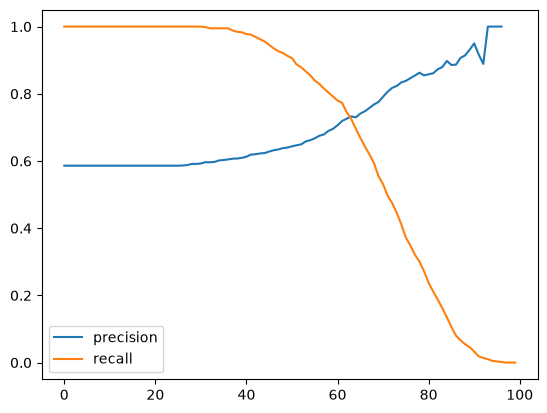

In [85]:
plt.plot(scores_df.precision, label = 'precision')
plt.plot(scores_df.recall, label = 'recall')
plt.legend()
plt.show()

In [91]:
scores_df['abs_diff'] = abs(scores_df['precision'] - scores_df['recall'])
scores_df.sort_values(by = 'abs_diff')

                

,thresh,precision,recall,abs_diff
63,0.63,0.732759,0.725256,0.007503
62,0.62,0.725914,0.745734,0.019820
64,0.64,0.729875,0.696246,0.033629
61,0.61,0.719048,0.773038,0.053990
65,0.65,0.741021,0.668942,0.072079
...,...,...,...,...
95,0.95,1.000000,0.003413,0.996587
96,0.96,1.000000,0.001706,0.998294
97,0.97,NaN,0.000000,NaN
98,0.98,NaN,0.000000,NaN


# 4. F1 Score
precision and recall are conflicting - when one grows, the other goes down. thats why they are often combined into the f1 score, a metric that takes into account both

f1 = 2 * (p*r)/(p+r) where p = precision and r = recall
lets compute f1 for all thresholds from 0 to 1 with increment 0.01
at which threshold is f1 maximal

In [94]:
thresholds = np.arange(0, 1.0, 0.01)

scores = []
for thresh in thresholds:

    pos = (y_pred >= thresh)
    neg = (y_pred < thresh)
    tp = (pos & (y_val == 1)).sum()
    fp = (pos & (y_val == 0)).sum()
    tn = (neg & (y_val == 0)).sum()
    fn = (neg & (y_val == 1)).sum()
    
    precision = tp/(tp+fp)
    recall = tp/(tp+fn)
    precision, recall
    f1 = 2*((precision*recall)/(precision+recall))
    scores.append((thresh, precision, recall, f1))
f1_scores_df = pd.DataFrame(scores)
f1_scores_df.columns = ['thresh','precision','recall','f1']
f1_scores_df.sort_values(by ='f1',ascending = False)
                    

/tmp/ipykernel_42523/108545391.py:13: RuntimeWarning: invalid value encountered in scalar divide
  precision = tp/(tp+fp)


,thresh,precision,recall,f1
41,0.41,0.619048,0.976109,0.757616
42,0.42,0.620087,0.969283,0.756325
43,0.43,0.622517,0.962457,0.756032
45,0.45,0.628118,0.945392,0.754768
44,0.44,0.623608,0.955631,0.754717
...,...,...,...,...
95,0.95,1.000000,0.003413,0.006803
96,0.96,1.000000,0.001706,0.003407
97,0.97,NaN,0.000000,NaN
98,0.98,NaN,0.000000,NaN


# 5. 5-fold CV
use the kfold class from sklearn to evaluate our model on 5 different folds
iterate over different folds of df_full_train
split the data into train and validation
train the model on train with usual params
use AUC to evaluate the model on validation
how large is the standard deviation of the scores across different folds?

In [96]:
from sklearn.model_selection import KFold
kfold = KFold(n_splits = 5, shuffle = True, random_state = 1)
def train(df_train, y_train, C = 1.0):
    dicts = df_train[categorical + numerical].to_dict(orient = 'records')

    dv = DictVectorizer(sparse = False)
    X_train = dv.fit_transform(dicts)

    model = LogisticRegression(solver = 'liblinear', C=C, max_iter = 1000)
    model.fit(X_train, y_train)

    return dv, model

def predict(df, dv, model):
    dicts = df[categorical + numerical].to_dict(orient = 'records')

    X=dv.transform(dicts)
    y_pred = model.predict_proba(X)[:,1]

    return y_pred

In [98]:
scores = []

for train_idx, val_idx in kfold.split(df_full_train):
    df_train = df_full_train.reset_index().iloc[train_idx].copy()
    df_val = df_full_train.reset_index().iloc[val_idx].copy()
    
    y_train = df_train.converted.values
    y_val = df_val.converted.values

    dv, model = train(df_train,y_train)
    y_pred = predict(df_val, dv, model)

    auc = roc_auc_score(y_val, y_pred)
    scores.append(auc)

In [100]:
np.std(scores)

np.float64(0.006853233151022138)

## Best C

In [103]:
n_splits = 5
for C in [0.000001, 0.001, 1]:
    scores = []
    kfold = KFold(n_splits = n_splits, shuffle = True, random_state = 1)
    for train_idx, val_idx in kfold.split(df_full_train):
        df_train = df_full_train.reset_index().iloc[train_idx].copy()
        df_val = df_full_train.reset_index().iloc[val_idx].copy()
        
        y_train = df_train.converted.values
        y_val = df_val.converted.values
    
        dv, model = train(df_train,y_train)
        y_pred = predict(df_val, dv, model)
    
        auc = roc_auc_score(y_val, y_pred)
        scores.append(auc)
    print(C, np.mean(scores), np.std(scores))

1e-06 0.7317269710972524 0.006853233151022138
0.001 0.7317269710972524 0.006853233151022138
1 0.7317269710972524 0.006853233151022138
